<a href="https://colab.research.google.com/github/Aum121221/HF_agents_course/blob/minor_updates/party_theme_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install smolagents -U
!pip install ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 73.7 MB/s eta 0:00:00


In [4]:
from getpass import getpass
from smolagents import CodeAgent, OpenAIModel, tool

OPENROUTER_API_KEY = getpass("Enter your OpenRouter API key: ")

@tool
def catering_service_tool(query: str) -> str:
    """
    This tool returns the highest-rated catering service in Gotham City.

    Args:
        query: A search term for finding catering services.
    """
    services = {
        "Gotham Catering Co.": 4.9,
        "Wayne Manor Catering": 4.8,
        "Gotham City Events": 4.7,
    }

    best_service = max(services, key=services.get)
    return best_service


model = OpenAIModel(
    model_id="openrouter/free",
    api_base="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

agent = CodeAgent(tools=[catering_service_tool], model=model)

result = agent.run(
    "Can you give me the name of the highest-rated catering service in Gotham City?"
)

print(result)

Enter your OpenRouter API key: ··········


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Can you give me the name of the highest-rated catering service in Gotham City?                                  │
│                                                                                                                 │
╰─ OpenAIModel - openrouter/free ─────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  catering_service = catering_service_tool(query="highest-rated catering service in Gotham City")                  
  print(catering_service)                                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Gotham Catering Co.

Out: None

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Gotham Catering Co.")                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Gotham Catering Co.

[Step 2: Duration 7.68 seconds| Input tokens: 4,491 | Output tokens: 364]

Gotham Catering Co.


In [ ]:
import os

# Get keys for your project from the project settings page: https://cloud.langfuse.com
os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-lf-4f064140-e28b-4c90-9ee1-0ed0d7b0662a"

os.environ["LANGFUSE_SECRET_KEY"] = "sk-lf-58531192-0a64-4944-a021-5f3284a50214"

os.environ["LANGFUSE_HOST"] = "https://cloud.langfuse.com" # 🇪🇺 EU region
# os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com" # 🇺🇸 US region


In [ ]:
!pip install langfuse
from langfuse import get_client

langfuse = get_client()

# Verify connection
if langfuse.auth_check():
    print("Langfuse client is authenticated and ready!")
else:
    print("Authentication failed. Please check your credentials and host.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.2/481.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.1.2
    Uninstalling wrapt-2.1.2:
      Successfully uninstalled wrapt-2.1.2
Langfuse client is authenticated and ready!


In [8]:
from smolagents import Tool, CodeAgent, OpenAIModel

class SuperheroPartyThemeTool(Tool):
    name = "superhero_party_theme_generator"
    description = """
    This tool suggests creative superhero-themed party ideas based on a category.
    It returns a unique party theme idea."""

    inputs = {
        "category": {
            "type": "string",
            "description": "The type of superhero party (e.g., 'classic heroes', 'villain masquerade', 'futuristic Gotham').",
        }
    }

    output_type = "string"

    def forward(self, category: str):
        themes = {
            "classic heroes": "Justice League Gala: Guests come dressed as their favorite DC heroes with themed cocktails like 'The Kryptonite Punch'.",
            "villain masquerade": "Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.",
            "futuristic Gotham": "Neo-Gotham Night: A cyberpunk-style party inspired by Batman Beyond, with neon decorations and futuristic gadgets."
        }

        return themes.get(category.lower(), "Themed party idea not found. Try 'classic heroes', 'villain masquerade', or 'futuristic Gotham'.")


party_theme_tool = SuperheroPartyThemeTool()

model = OpenAIModel(
    model_id="openrouter/free", # Changed model_id to 'openrouter/free'
    api_base="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

agent = CodeAgent(tools=[party_theme_tool], model=model)

result = agent.run(
    "What would be a good superhero party idea for a 'villain masquerade' theme?"
)

print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What would be a good superhero party idea for a 'villain masquerade' theme?                                     │
│                                                                                                                 │
╰─ OpenAIModel - openrouter/free ─────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  theme = superhero_party_theme_generator(category="villain masquerade")                                           
  final_answer(theme)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.

[Step 1: Duration 3.12 seconds| Input tokens: 2,161 | Output tokens: 259]

Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.


In [12]:
from getpass import getpass

HF_TOKEN = getpass("Enter your Hugging Face token: ")

party_theme_tool.push_to_hub(
    "Aum121221/party_theme_tool",
    token=HF_TOKEN
)

Enter your Hugging Face token: ··········


README.md:   0%|          | 0.00/260 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/spaces/Aum121221/party_theme_tool/commit/6ca50078cffa8be79122ba164e778b2e41ece742', commit_message='Upload tool', commit_description='', oid='6ca50078cffa8be79122ba164e778b2e41ece742', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/Aum121221/party_theme_tool', endpoint='https://huggingface.co', repo_type='space', repo_id='Aum121221/party_theme_tool'), pr_revision=None, pr_num=None)

Enter your Hugging Face token: ··········


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.                 │
│                                                                                                                 │
╰─ OpenAIModel - openrouter/free ─────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prompt = (                                                                                                       
      "A lavish, superhero-themed gala at Wayne Manor, grand ballroom illuminated by crystal chandeliers, "        
      "elegant guests dressed as original, made‑up superheroes with vibrant costumes, "                            
      "extravagant decorations like floating neon symbols, a giant comic‑book style banner reading 'Heroes         
  Unite', "                                                                                                        
      "plush velvet ropes, ornate gilded railings, and a view of the iconic manor exterior through large windows,  
  "                                                                                                                
      "high‑resolution, photorealistic, cinematic lighting"                                                        
  )                                                                                                                
  image = image_generator(prompt)                                                                                  
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x7E1A03482240>

[Step 1: Duration 8.20 seconds| Input tokens: 2,116 | Output tokens: 145]

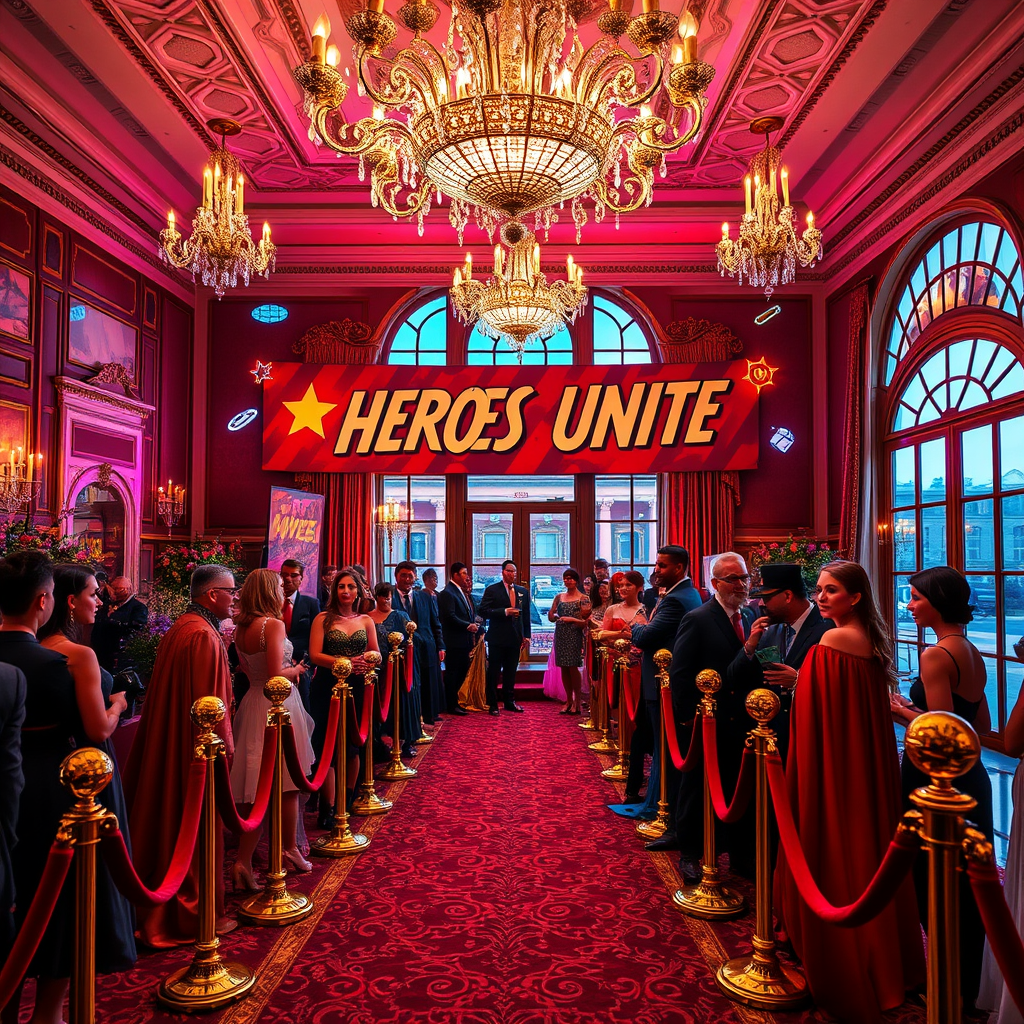

In [18]:
from getpass import getpass
from huggingface_hub import login
from smolagents import load_tool, CodeAgent, OpenAIModel

HF_TOKEN = getpass("Enter your Hugging Face token: ")

login(token=HF_TOKEN)

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code=True,
    token=HF_TOKEN,
)

model = OpenAIModel(
    model_id="openrouter/free", # Changed model_id to 'openrouter/free'
    api_base="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)
agent = CodeAgent(
    tools=[image_generation_tool],
    model=model,
)

agent.run(
    "Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros."
)

In [25]:
from smolagents import CodeAgent, OpenAIModel, Tool

image_generation_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt",
)

model = OpenAIModel(
    model_id="openrouter/free",
    api_base="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=model,
)

agent.run(
    "Use the image_generator tool once with only the prompt argument. "
    "Prompt: A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala"
)

Loaded as API: https://black-forest-labs-flux-1-schnell.hf.space ✔


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Use the image_generator tool once with only the prompt argument. Prompt: A grand superhero-themed party at      │
│ Wayne Manor, with Alfred overseeing a luxurious gala                                                            │
│                                                                                                                 │
╰─ OpenAIModel - openrouter/free ─────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Error in code parsing:
expected string or bytes-like object, got 'NoneType'
Make sure to provide correct code blobs.

[Step 1: Duration 8.10 seconds| Input tokens: 2,136 | Output tokens: 129]

...

Error in code parsing:
expected string or bytes-like object, got 'NoneType'
Make sure to provide correct code blobs.

[Step 3: Duration 11.67 seconds| Input tokens: 6,719 | Output tokens: 419]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 4 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[Step 4: Duration 15.53 seconds]

KeyboardInterrupt: 

In [26]:
pip install -U langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [41]:
!pip install -q langchain-community google-search-results

  Preparing metadata (setup.py) ... done


In [43]:
from getpass import getpass
from langchain_community.utilities import SerpAPIWrapper

SERPAPI_API_KEY = getpass("Enter your SerpAPI key: ")

serpapi = SerpAPIWrapper(serpapi_api_key=SERPAPI_API_KEY)

results = serpapi.run(
    "luxury entertainment ideas for a superhero-themed event live performances interactive experiences"
)

print(results)

Enter your SerpAPI key: ··········
[{'title': 'The UP-CLOSE Magic Experience', 'type': 'Magic show', 'date': 'Jun 20', 'time': '2:30 PM', 'address': ['Renaissance Phoenix Downtown Hotel', 'Downtown Phoenix'], 'thumbnail': 'https://serpapi.com/searches/6a1ee5739df9dd476ee97113/images/S1B3et4IH7HVcJAzkEinN5lOo_EsSh8sWID1ewqm4Jg.jpeg'}, {'title': 'Anamnesis', 'type': 'Dinner with magic show', 'date': 'Jun 20', 'time': '6:00 PM', 'address': ['The Old Spaghetti Factory', 'Downtown Phoenix'], 'thumbnail': 'https://serpapi.com/searches/6a1ee5739df9dd476ee97113/images/pvsJLAZyQJTSXfK0iGosB4bx3ae0jz4vccg0cTgZ29U.jpeg'}, {'title': 'Superman', 'type': 'Classic movie screening', 'date': 'Jun 14', 'time': '2:30 PM', 'address': ['Orpheum Theatre Phoenix', 'Downtown Phoenix'], 'thumbnail': 'https://serpapi.com/searches/6a1ee5739df9dd476ee97113/images/CtP9Ego8L-_iay1V8XfqfymUrpcJubr7nSS0tWGl6EU.jpeg'}, {'title': 'Guardians of the Galaxy', 'type': 'Superhero film screening', 'date': 'Jun 21', 'time': '

In [49]:
from getpass import getpass
from langchain_community.utilities import SerpAPIWrapper
from smolagents import CodeAgent, OpenAIModel, tool

SERPAPI_API_KEY = getpass("Enter your SerpAPI key: ")

serpapi = SerpAPIWrapper(serpapi_api_key=SERPAPI_API_KEY)

@tool
def search_web(query: str) -> str:
    """
    Search the web using SerpAPI.

    Args:
        query: The search query.
    """
    return serpapi.run(query)


model = OpenAIModel(
    model_id="openrouter/free",
    api_base="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

agent = CodeAgent(tools=[search_web], model=model)

agent.run(
    "Search for luxury entertainment ideas for a superhero-themed event, "
    "such as live performances and interactive experiences."
)

Enter your SerpAPI key: ··········


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Search for luxury entertainment ideas for a superhero-themed event, such as live performances and interactive   │
│ experiences.                                                                                                    │
│                                                                                                                 │
╰─ OpenAIModel - openrouter/free ─────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Error in code parsing:
expected string or bytes-like object, got 'NoneType'
Make sure to provide correct code blobs.

[Step 1: Duration 4.38 seconds| Input tokens: 2,080 | Output tokens: 89]

...

Execution logs:
[{'title': "Houston's Theatre of Magic at the JW Marriott", 'type': 'Magic show', 'date': 'Jun 6', 'time': '7:30 
PM', 'address': ['JW Marriott Houston Downtown', 'Downtown Houston'], 'thumbnail': 
'https://serpapi.com/searches/6a1ee8cf9f070066c644b8bc/images/dWrK9cBHGI46eW5-wJ8T-uZ6-Fz5Y0D1eZJZ4A13Vrw.jpeg'}, 
{'title': 'The Magic Of Robby Bennett', 'type': 'Magic and comedy show', 'date': 'Jun 14', 'time': '4:00 PM', 
'address': ['Standing Ovation Theatre', 'Houston, TX'], 'thumbnail': 
'https://serpapi.com/searches/6a1ee8cf9f070066c644b8bc/images/VLJkGYBfvpMGrDUmAhcsEpUEfzLADKV77P4_KsN6Opk.jpeg'}, 
{'title': 'Ringling Bros and Barnum and Bailey Circus', 'type': 'Circus performance', 'date': 'Aug 8', 'time': 
'11:00 AM', 'address': ['Houston Stadium', 'Houston, TX'], 'thumbnail': 
'https://serpapi.com/searches/6a1ee8cf9f070066c644b8bc/images/lhxf0xgaaEOmiKAezSYXf9NRUGObKIo7VGUO3BDFboE.jpeg'}, 
{'title': 'My Hero Academia In Concert', 'type': 'Anime music concert', 'date': 'Oct 8', 'time': '7:30 PM', 
'address': ['Smart Financial Centre at Sugar Land', 'Sugar Land, TX'], 'thumbnail': 
'https://serpapi.com/searches/6a1ee8cf9f070066c644b8bc/images/WK_hyLHc7vjjKcbZXQ1qvmjd_Fk10atteerl6drJiHY.jpeg'}, 
{'title': 'Haute & Freddy', 'type': 'Theatrical performance', 'date': 'Sep 19', 'time': '7:00 PM', 'address': ['The
Heights Villa', 'Houston, TX'], 'thumbnail': 
'https://encrypted-tbn3.gstatic.com/images?q=tbn:ANd9GcSWs5dz37ZGvz8AtWAFEbb43JryRUGlxqbmm6XybrjLgAflc_UXQ3bVRiNrta
GbiSN_OyPBCwwMgwdljpc'}, {'title': 'Cirque Alice', 'type': 'Acrobatic performance', 'date': 'Mar 27', 'time': 
'10:00 AM', 'address': ['Jones Hall for the Performing Arts', 'Downtown Houston'], 'thumbnail': 
'https://encrypted-tbn1.gstatic.com/images?q=tbn:ANd9GcQXziVcZ2hEgi9XmfP7uTKg01r4dBR-2cnRnXw-mlq26s0H_rwm9UgSNXRcqb
3_kbAOcQostB2ntz-SZZs'}, {'title': 'Fantasy Soiree Houston Edition', 'type': 'Themed social gathering', 'date': 
'Jul 23', 'time': '6:00 PM', 'address': ['Charmelle Chateau Dynasty', 'Downtown Houston'], 'thumbnail': 
'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRivlEYz3mVtrtKXcRS3_6i-R_GmxY6N3VNXmuDCcp0iSy-HXVzK39KXjqjrq
8ERcKl-IgujrjxwZxb0b4'}, {'title': 'Miracles Masquerade: Unmasking Hope Black Tie Gala', 'type': 'Charity gala', 
'date': 'Jun 6', 'time': '6:00 PM', 'address': ['Hilton Houston Post Oak by the Galleria', 'Greater Uptown'], 
'thumbnail': 
'https://encrypted-tbn1.gstatic.com/images?q=tbn:ANd9GcQfp5Et78lJGyLxy9kAX0iVJAb0HEnwFVqvCzYcF0YIoCMmhmILleGWZ9jkcx
BaOlIHumX_cIBFJLbVycE'}, {'title': 'Harry Potter and the Cursed Child', 'type': 'Wizarding world play', 'date': 
'Jun 12', 'time': '7:30 PM', 'address': ['The Hobby Center for the Performing Arts', 'Downtown Houston'], 
'thumbnail': 
'https://encrypted-tbn3.gstatic.com/images?q=tbn:ANd9GcTZk7C1Mb5Ie3E2I4_4bX_kUHE5Zhs_L0fQKy-oJ6AIW96sjTB6pPcdMzNr6c
Ow1v9L8ueNWjsOLevw_s4'}, {'title': 'Alton Brown', 'type': 'Live performance', 'date': 'Nov 13', 'time': '7:30 PM', 
'address': ['Jones Hall for the Performing Arts', 'Downtown Houston'], 'thumbnail': 
'https://encrypted-tbn1.gstatic.com/images?q=tbn:ANd9GcRJRSsEEGN3uqSHNtBeAEE2hcbHN2Ngjpp8X-igQ3dQBXII09e9xZ-Az0SWqZ
QmxnoZOOLnsHiDsFXISoc'}]

Out: None

[Step 2: Duration 6.95 seconds| Input tokens: 4,213 | Output tokens: 219]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[Step 3: Duration 23.39 seconds]

KeyboardInterrupt: 

In [55]:
import os
from smolagents import ToolCollection, CodeAgent, OpenAIModel
from mcp import StdioServerParameters

model = OpenAIModel(
    model_id="openrouter/free",
    api_base="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

server_parameters = StdioServerParameters(
    command="uvx",
    args=["--quiet", "pubmedmcp@0.1.3"],
    env={"UV_PYTHON": "3.12", **os.environ},

)

with ToolCollection.from_mcp(server_parameters, trust_remote_code=True) as tool_collection:
    agent = CodeAgent(
        tools=[*tool_collection.tools],
        model=model,
        add_base_tools=True,
        max_steps=3,
    )
    agent.run("Please find evidence-based remedies for a hangover.")

/usr/lib/python3.12/contextlib.py:137: FutureWarning: Parameter 'structured_output' was not specified. Currently it defaults to False, but in version 1.25, the default will change to True. To suppress this warning, explicitly set structured_output=True (new behavior) or structured_output=False (legacy behavior). See documentation at https://huggingface.co/docs/smolagents/tutorials/tools#structured-output-and-output-schema-support for more details.
  return next(self.gen)
Exception in thread Thread-25 (_run_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/mcpadapt/core.py", line 244, in _run_loop
    self.loop.run_until_complete(self.task)
  File "/usr/lib/python3.12/asyncio/base_events.py", line 691, in run_until_complete
    return future.result()
    

TimeoutError: Couldn't connect to the MCP server after 30 seconds